In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q opencv-python-headless tqdm

In [3]:
import os
import cv2
import glob
import json
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
PROJECT_ROOT = '/content/drive/MyDrive/Sketch2Face'

RAW_SKETCH_DIR = os.path.join(PROJECT_ROOT, 'dataset', 'sketches')
RAW_PHOTO_DIR  = os.path.join(PROJECT_ROOT, 'dataset', 'photos')

PROCESSED_DIR  = os.path.join(PROJECT_ROOT, 'dataset', 'processed')
PROC_SKETCH    = os.path.join(PROCESSED_DIR, 'sketches')
PROC_PHOTO     = os.path.join(PROCESSED_DIR, 'photos')

SPLIT_DIR      = os.path.join(PROJECT_ROOT, 'dataset', 'split')
TRAIN_SKETCH   = os.path.join(SPLIT_DIR, 'train', 'sketches')
TRAIN_PHOTO    = os.path.join(SPLIT_DIR, 'train', 'photos')
TEST_SKETCH    = os.path.join(SPLIT_DIR, 'test',  'sketches')
TEST_PHOTO     = os.path.join(SPLIT_DIR, 'test',  'photos')

for d in [PROC_SKETCH, PROC_PHOTO,
          TRAIN_SKETCH, TRAIN_PHOTO,
          TEST_SKETCH,  TEST_PHOTO]:
    os.makedirs(d, exist_ok=True)

CONFIG = {
    'image_size'  : 256,
    'train_ratio' : 0.80,
    'test_ratio'  : 0.20,
    'random_seed' : 42,
}

VALID_EXTS = {'.png', '.jpg', '.jpeg', '.bmp'}

print('Project root  :', PROJECT_ROOT)
print('Raw sketches  :', RAW_SKETCH_DIR)
print('Raw photos    :', RAW_PHOTO_DIR)
print('Processed dir :', PROCESSED_DIR)
print('Split dir     :', SPLIT_DIR)
print('Config        :', CONFIG)

Project root  : /content/drive/MyDrive/Sketch2Face
Raw sketches  : /content/drive/MyDrive/Sketch2Face/dataset/sketches
Raw photos    : /content/drive/MyDrive/Sketch2Face/dataset/photos
Processed dir : /content/drive/MyDrive/Sketch2Face/dataset/processed
Split dir     : /content/drive/MyDrive/Sketch2Face/dataset/split
Config        : {'image_size': 256, 'train_ratio': 0.8, 'test_ratio': 0.2, 'random_seed': 42}


In [5]:
def normalize_sketch_name(name):
    """
    Normalize sketch filename stem so it matches the corresponding photo stem.
      sketch M2-005-sz1 -> m-005
      sketch F2-005-sz1 -> f-005
    """
    name = name.lower()
    name = name.replace("-sz1", "")
    if name.startswith("m2"):
        name = name.replace("m2", "m", 1)
    if name.startswith("f2"):
        name = name.replace("f2", "f", 1)
    return name


def preprocess_image(img_path, img_size, is_sketch=False):
    """
    Load -> Resize -> Grayscale (sketch only).
    Returns uint8 numpy array (H, W, 3) in [0, 255].

    NOTE: No normalization here — normalization to [-1,1]
    is done in augmentation.py at training time.
    """
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f'Cannot read: {img_path}')

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LANCZOS4)

    if is_sketch:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        img  = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    return img.astype(np.uint8)


print('Helper functions defined.')

Helper functions defined.


In [6]:
def stem(path):
    return os.path.splitext(os.path.basename(path))[0]

sketch_files = [p for p in glob.glob(os.path.join(RAW_SKETCH_DIR, '**', '*'), recursive=True)
                if os.path.splitext(p)[1].lower() in VALID_EXTS]
photo_files  = [p for p in glob.glob(os.path.join(RAW_PHOTO_DIR, '**', '*'), recursive=True)
                if os.path.splitext(p)[1].lower() in VALID_EXTS]

sketch_map = {normalize_sketch_name(stem(p)): p for p in sketch_files}
photo_map  = {stem(p):  p for p in photo_files}

common_ids  = sorted(set(sketch_map.keys()) & set(photo_map.keys()))
sketch_only = set(sketch_map.keys()) - set(photo_map.keys())
photo_only  = set(photo_map.keys())  - set(sketch_map.keys())

paired_raw = [
    {'id': sid, 'sketch': sketch_map[sid], 'photo': photo_map[sid]}
    for sid in common_ids
]

print(f'Sketches found         : {len(sketch_files)}')
print(f'Photos found           : {len(photo_files)}')
print(f'Valid matched pairs    : {len(paired_raw)}')
print(f'Sketches without photo : {len(sketch_only)}')
print(f'Photos without sketch  : {len(photo_only)}')

if sketch_only:
    print(f'  Unmatched sketches : {sorted(sketch_only)}')
if photo_only:
    print(f'  Unmatched photos   : {sorted(photo_only)}')

Sketches found         : 188
Photos found           : 188
Valid matched pairs    : 188
Sketches without photo : 0
Photos without sketch  : 0


In [7]:
IMG_SIZE = CONFIG['image_size']

paired_processed = []
failed           = []

for pair in tqdm(paired_raw, desc='Preprocessing'):
    sid        = pair['id']
    out_sketch = os.path.join(PROC_SKETCH, f'{sid}.png')
    out_photo  = os.path.join(PROC_PHOTO,  f'{sid}.png')

    try:
        sketch_arr = preprocess_image(pair['sketch'], IMG_SIZE, is_sketch=True)
        photo_arr  = preprocess_image(pair['photo'],  IMG_SIZE, is_sketch=False)

        cv2.imwrite(out_sketch, cv2.cvtColor(sketch_arr, cv2.COLOR_RGB2BGR))
        cv2.imwrite(out_photo,  cv2.cvtColor(photo_arr,  cv2.COLOR_RGB2BGR))

        paired_processed.append({'id': sid, 'sketch': out_sketch, 'photo': out_photo})

    except Exception as e:
        failed.append({'id': sid, 'error': str(e)})
        print(f'  FAILED: {sid} — {e}')

print(f'\nPreprocessed successfully : {len(paired_processed)}')
print(f'Failed                    : {len(failed)}')

Preprocessing: 100%|██████████| 188/188 [01:06<00:00,  2.83it/s]


Preprocessed successfully : 188
Failed                    : 0


In [8]:
errors = []

for pair in tqdm(paired_processed, desc='Verifying'):
    for key in ('sketch', 'photo'):
        img = cv2.imread(pair[key])
        if img is None:
            errors.append(f"Cannot read: {pair[key]}")
            continue
        h, w, c = img.shape
        if h != IMG_SIZE or w != IMG_SIZE:
            errors.append(f"Wrong size {w}x{h}: {pair[key]}")
        if c != 3:
            errors.append(f"Expected 3 channels, got {c}: {pair[key]}")
        if img.dtype != np.uint8:
            errors.append(f"Expected uint8, got {img.dtype}: {pair[key]}")

if errors:
    for e in errors:
        print(f'  ERROR: {e}')
else:
    sample  = paired_processed[0]
    s_arr   = cv2.imread(sample['sketch'])
    p_arr   = cv2.imread(sample['photo'])
    print(f'Sample sketch — shape: {s_arr.shape}, dtype: {s_arr.dtype}, range: [{s_arr.min()}, {s_arr.max()}]')
    print(f'Sample photo  — shape: {p_arr.shape}, dtype: {p_arr.dtype}, range: [{p_arr.min()}, {p_arr.max()}]')
    print(f'\nAll {len(paired_processed)} preprocessed images verified OK.')
    print('Pixel range is [0, 255] uint8 — normalization will be applied in augmentation.py')

Verifying: 100%|██████████| 188/188 [00:03<00:00, 47.11it/s]

Sample sketch — shape: (256, 256, 3), dtype: uint8, range: [8, 255]
Sample photo  — shape: (256, 256, 3), dtype: uint8, range: [0, 255]

All 188 preprocessed images verified OK.
Pixel range is [0, 255] uint8 — normalization will be applied in augmentation.py


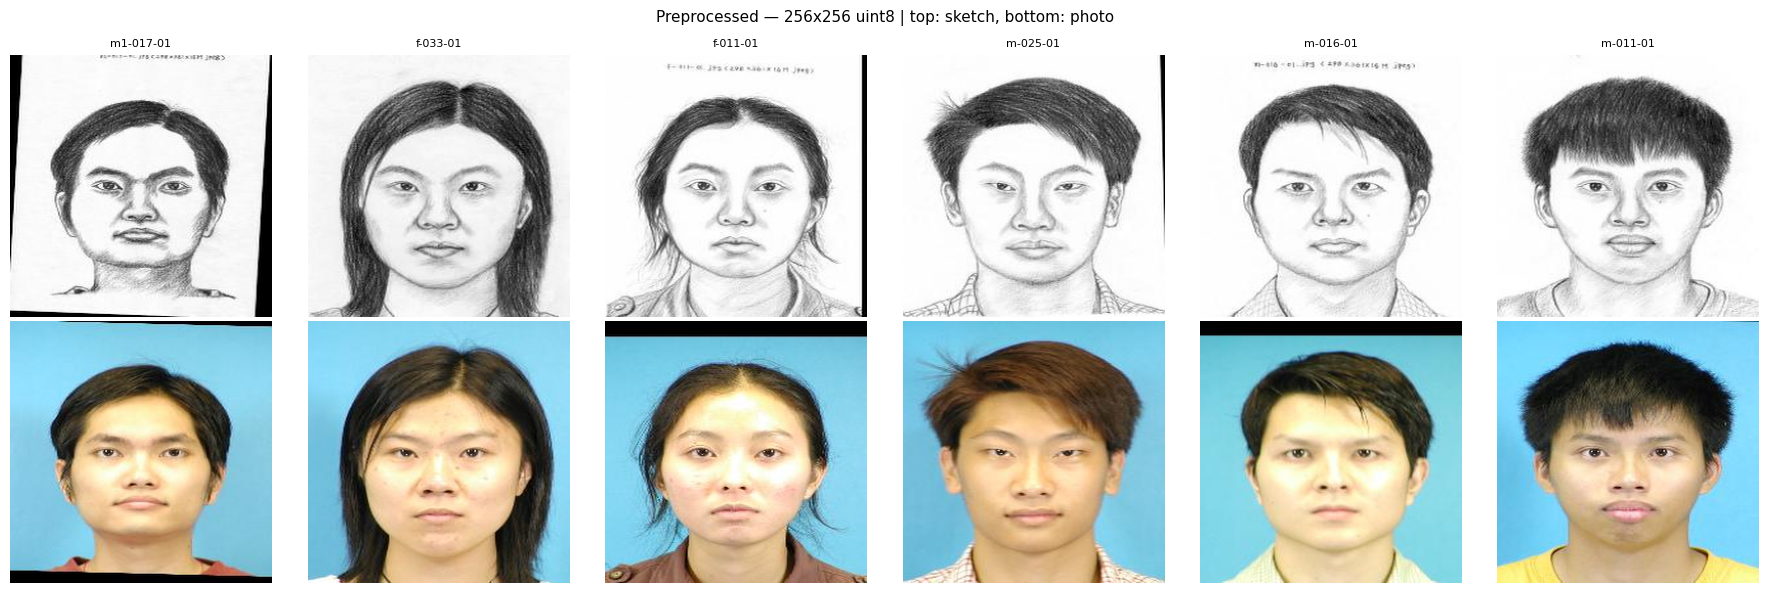

In [9]:
random.seed(CONFIG['random_seed'])
samples = random.sample(paired_processed, min(6, len(paired_processed)))

fig, axes = plt.subplots(2, len(samples), figsize=(len(samples) * 3, 6))
fig.suptitle(f'Preprocessed — {IMG_SIZE}x{IMG_SIZE} uint8 | top: sketch, bottom: photo', fontsize=11)

for i, pair in enumerate(samples):
    sketch_disp = cv2.cvtColor(cv2.imread(pair['sketch']), cv2.COLOR_BGR2GRAY)
    photo_disp  = cv2.cvtColor(cv2.imread(pair['photo']),  cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(sketch_disp, cmap='gray')
    axes[0, i].set_title(pair['id'], fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(photo_disp)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Sketch', fontsize=10)
axes[1, 0].set_ylabel('Photo',  fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
random.seed(CONFIG['random_seed'])
shuffled = paired_processed.copy()
random.shuffle(shuffled)

n_total = len(shuffled)
n_test  = max(1, round(n_total * CONFIG['test_ratio']))
n_train = n_total - n_test

train_pairs = shuffled[:n_train]
test_pairs  = shuffled[n_train:]

print(f'Total : {n_total}  |  Train : {n_train}  |  Test : {n_test}')
print()

def copy_split(pairs, sketch_dir, photo_dir, split_name):
    for pair in tqdm(pairs, desc=f'Copying {split_name}'):
        shutil.copy2(pair['sketch'], os.path.join(sketch_dir, f"{pair['id']}.png"))
        shutil.copy2(pair['photo'],  os.path.join(photo_dir,  f"{pair['id']}.png"))

copy_split(train_pairs, TRAIN_SKETCH, TRAIN_PHOTO, 'train')
copy_split(test_pairs,  TEST_SKETCH,  TEST_PHOTO,  'test')

print(f'\nTrain copied -> {TRAIN_SKETCH}')
print(f'Test  copied -> {TEST_SKETCH}')

Total : 188  |  Train : 150  |  Test : 38



Copying test: 100%|██████████| 38/38 [00:01<00:00, 24.13it/s]


Train copied -> /content/drive/MyDrive/Sketch2Face/dataset/split/train/sketches
Test  copied -> /content/drive/MyDrive/Sketch2Face/dataset/split/test/sketches


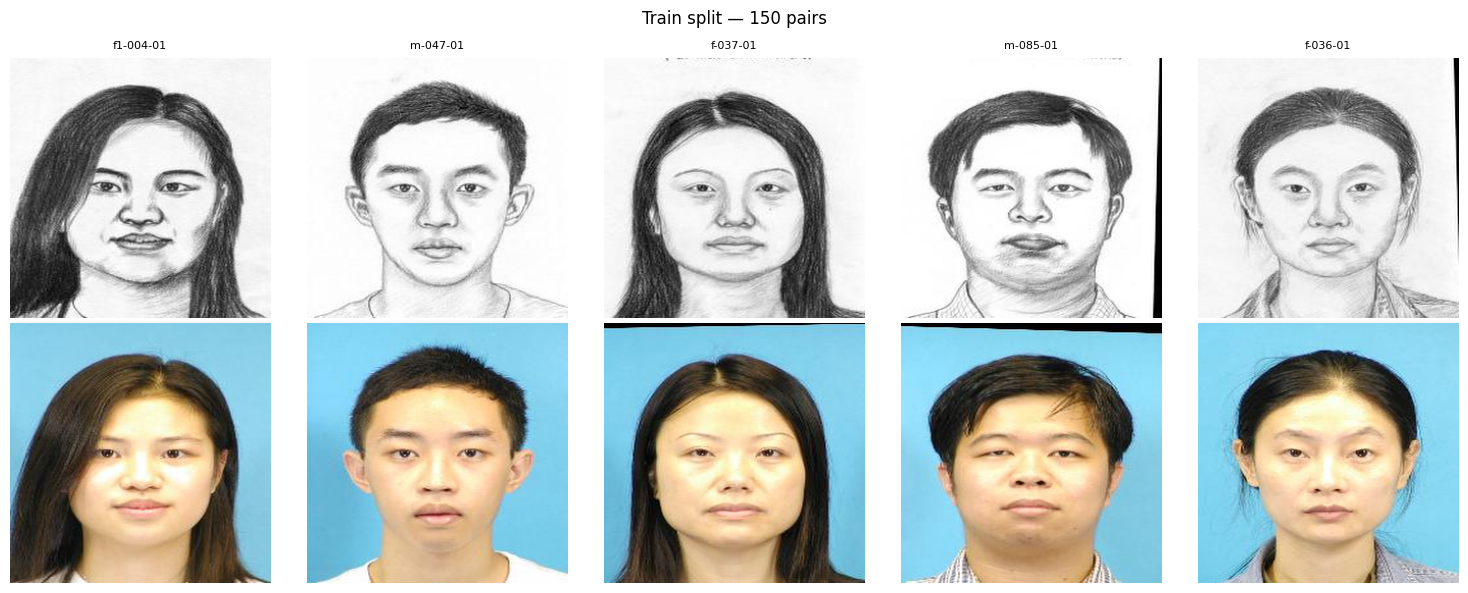

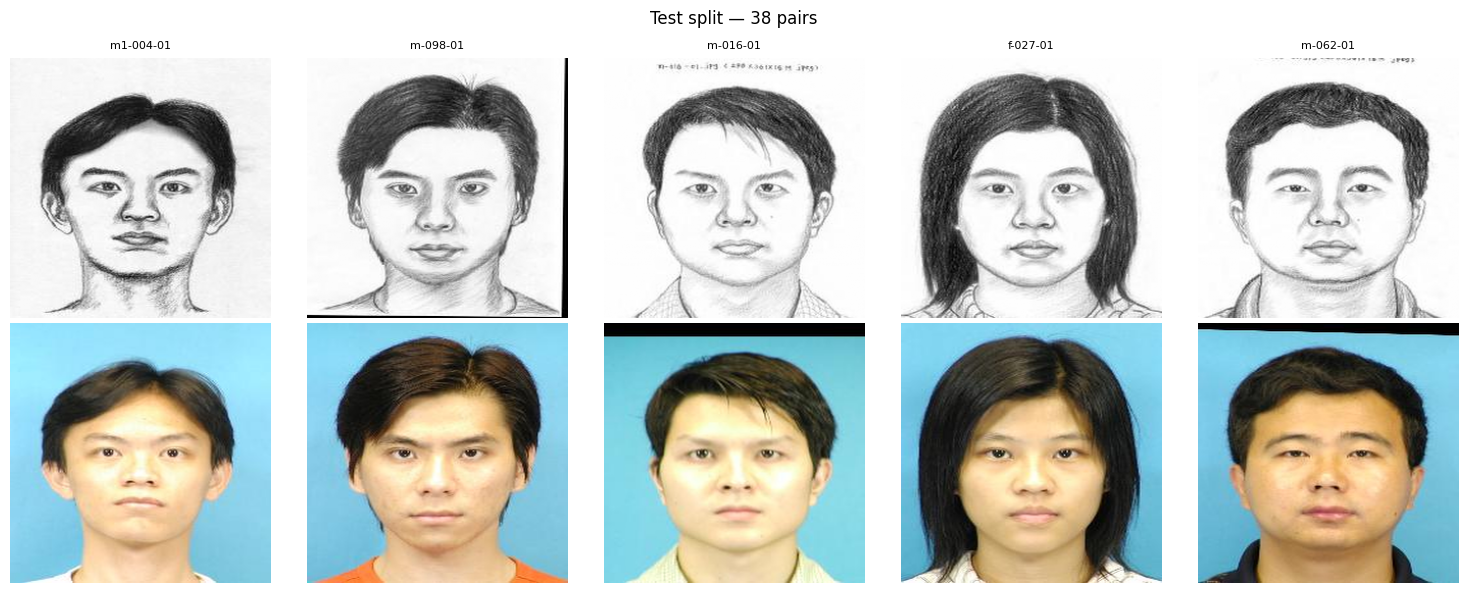

In [11]:
def show_split(pairs, split_name, n=5):
    samples = random.sample(pairs, min(n, len(pairs)))
    fig, axes = plt.subplots(2, len(samples), figsize=(len(samples) * 3, 6))
    fig.suptitle(f'{split_name} split — {len(pairs)} pairs', fontsize=12)
    for i, pair in enumerate(samples):
        dst_s = os.path.join(SPLIT_DIR, split_name.lower(), 'sketches', f"{pair['id']}.png")
        dst_p = os.path.join(SPLIT_DIR, split_name.lower(), 'photos',  f"{pair['id']}.png")
        axes[0, i].imshow(cv2.cvtColor(cv2.imread(dst_s), cv2.COLOR_BGR2GRAY), cmap='gray')
        axes[0, i].set_title(pair['id'], fontsize=8)
        axes[0, i].axis('off')
        axes[1, i].imshow(cv2.cvtColor(cv2.imread(dst_p), cv2.COLOR_BGR2RGB))
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Sketch', fontsize=10)
    axes[1, 0].set_ylabel('Photo',  fontsize=10)
    plt.tight_layout()
    plt.show()

show_split(train_pairs, 'Train')
show_split(test_pairs,  'Test')

In [12]:
print('=' * 55)
print('Preprocessing & Split Summary')
print('=' * 55)
print(f'Total pairs      : {len(paired_processed)}')
print(f'Train            : {len(train_pairs)}')
print(f'Test             : {len(test_pairs)}')
print()
print('Preprocessing applied:')
print(f'  Resize         : {IMG_SIZE}x{IMG_SIZE} (Lanczos)')
print(f'  Sketch mode    : Grayscale -> 3-channel RGB')
print(f'  Photo mode     : RGB')
print(f'  Saved as       : uint8 PNG [0, 255]  <-- no normalization')
print()
print('Handled later in augmentation.py:')
print('  Normalize      : [0,255] -> [-1,1]')
print('  Augmentation   : flip, rotate, crop (train only)')
print()
print('Folder structure:')
print(f'  dataset/processed/sketches/  : {len(paired_processed)} files')
print(f'  dataset/processed/photos/    : {len(paired_processed)} files')
print(f'  dataset/split/train/sketches/: {len(train_pairs)} files')
print(f'  dataset/split/train/photos/  : {len(train_pairs)} files')
print(f'  dataset/split/test/sketches/ : {len(test_pairs)} files')
print(f'  dataset/split/test/photos/   : {len(test_pairs)} files')
print('=' * 55)

Preprocessing & Split Summary
Total pairs      : 188
Train            : 150
Test             : 38

Preprocessing applied:
  Resize         : 256x256 (Lanczos)
  Sketch mode    : Grayscale -> 3-channel RGB
  Photo mode     : RGB
  Saved as       : uint8 PNG [0, 255]  <-- no normalization

Handled later in augmentation.py:
  Normalize      : [0,255] -> [-1,1]
  Augmentation   : flip, rotate, crop (train only)

Folder structure:
  dataset/processed/sketches/  : 188 files
  dataset/processed/photos/    : 188 files
  dataset/split/train/sketches/: 150 files
  dataset/split/train/photos/  : 150 files
  dataset/split/test/sketches/ : 38 files
  dataset/split/test/photos/   : 38 files
